# 09 — Null models: is the structure significant? (extends L6/L7)

**Semiconductor Supply Chain — Network Analysis**

Notebooks `02`–`08` report **descriptive** quantities (clustering, modularity,
articulation points, resilience). A descriptive number alone cannot say whether
what we see is *more than expected by chance*. This notebook closes that gap with
a **degree-preserving configuration null model** — the standard significance test
in network science.

**Idea.** Take the real `SUPPLIES` graph and randomly rewire its edges
(`nx.double_edge_swap`) so that **every node keeps its exact degree**, but *who
connects to whom* is randomized. This holds the degree sequence fixed, so any gap
between the observed value and the null ensemble is **structure beyond degree** —
not an artefact of a few high-degree hubs.

For each metric we build an ensemble of 150 rewired graphs, then report the
**z-score** = (observed − null mean) / null sd and an empirical **p-value**.
|z| > 2 (p < 0.05) ⇒ significantly different from the degree-preserving null.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'scripts' / 'analysis.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import analysis

D = analysis.company_supply_digraph()
U = D.to_undirected(as_view=False)
print(f'{U.number_of_nodes()} companies, {U.number_of_edges()} undirected SUPPLIES links')

108 companies, 1256 undirected SUPPLIES links


## 1. Metrics and the null ensemble

We test six quantities spanning the earlier notebooks:
clustering **C** (L7), average path length **L** (L7), Louvain modularity **Q**
(L5), number of **articulation points** (L4), targeted-attack **robustness**
(AUC of the giant component under degree-descending removal, L9), and **degree
assortativity**.

In [2]:
def robustness(G):
    # mean giant-component fraction under degree-targeted removal (lower = more fragile)
    H = G.copy(); N = H.number_of_nodes(); ys = [1.0]
    for n in [x for x, _ in sorted(H.degree(), key=lambda t: t[1], reverse=True)]:
        if n in H:
            H.remove_node(n)
        ys.append(max((len(c) for c in nx.connected_components(H)), default=0) / N)
    return float(np.mean(ys))

def metrics(G):
    gc = G if nx.is_connected(G) else G.subgraph(max(nx.connected_components(G), key=len)).copy()
    cm = nx.community.louvain_communities(G, seed=1, weight=None)
    return {
        'clustering C': nx.average_clustering(G),
        'avg path L': nx.average_shortest_path_length(gc),
        'modularity Q': nx.community.modularity(G, cm, weight=None),
        'articulation pts': len(list(nx.articulation_points(G))),
        'robustness (AUC)': robustness(G),
        'assortativity': nx.degree_assortativity_coefficient(G),
    }

obs = metrics(U)
m = U.number_of_edges()
rng = np.random.default_rng(7)
NULLS = 150
null = {k: [] for k in obs}
for _ in range(NULLS):
    R = U.copy()
    try:
        nx.double_edge_swap(R, nswap=10 * m, max_tries=200 * m, seed=int(rng.integers(1e9)))
    except nx.NetworkXAlgorithmError:
        pass
    mm = metrics(R)
    for k in obs:
        null[k].append(mm[k])

rows = []
for k in obs:
    a = np.array(null[k]); mu = a.mean(); sd = a.std() or 1e-9
    z = (obs[k] - mu) / sd
    p = min(1.0, 2 * min(np.mean(a >= obs[k]), np.mean(a <= obs[k])))
    rows.append([k, round(obs[k], 3), f'{mu:.3f} ± {sd:.3f}', round(z, 1),
                 round(p, 3), 'yes' if abs(z) > 2 else 'no'])
summary = pd.DataFrame(rows, columns=['metric', 'observed', 'null (mean ± sd)',
                                      'z', 'p (two-sided)', 'significant?'])
summary

,metric,observed,null (mean ± sd),z,p (two-sided),significant?
0,clustering C,0.086,0.355 ± 0.009,-30.4,0.00,yes
1,avg path L,1.991,1.869 ± 0.006,21.3,0.00,yes
2,modularity Q,0.220,0.128 ± 0.005,17.4,0.00,yes
3,articulation pts,1.000,1.000 ± 0.000,0.0,1.00,no
4,robustness (AUC),0.374,0.416 ± 0.007,-5.7,0.00,yes
5,assortativity,-0.117,-0.086 ± 0.023,-1.4,0.16,no


## 2. Visualise the null distributions

For the three significant continuous metrics, the histogram is the null ensemble;
the red line is the observed value. The further the line sits in the tail, the
more the property is *structure beyond degree*.

saved C:\Users\Max\Desktop\project\reports\figures\09_null_models.png


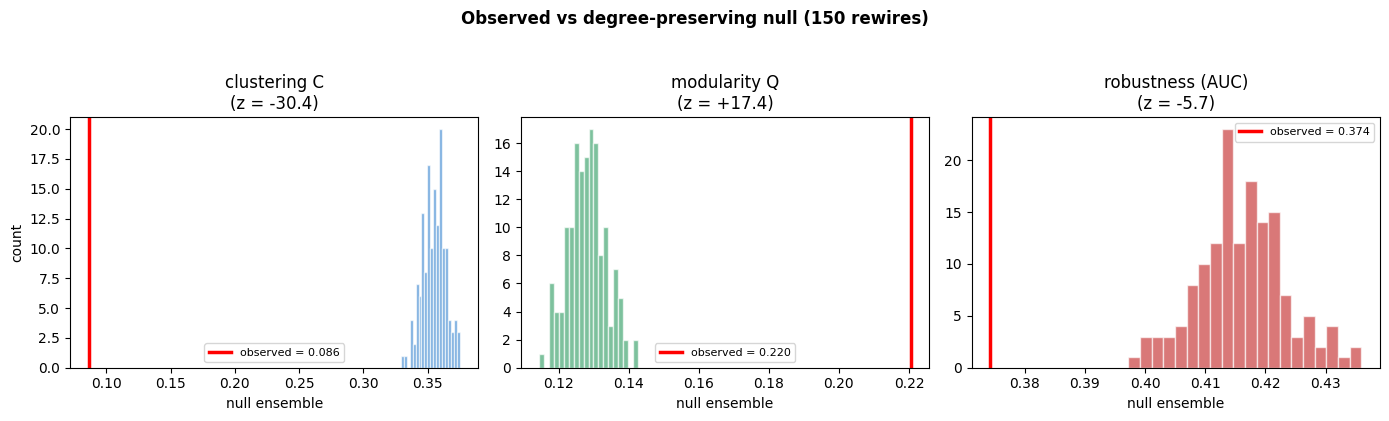

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, k, col in zip(axes, ['clustering C', 'modularity Q', 'robustness (AUC)'],
                      ['#3182ce', '#38a169', '#c53030']):
    a = np.array(null[k])
    ax.hist(a, bins=20, color=col, alpha=0.65, edgecolor='white')
    ax.axvline(obs[k], color='red', lw=2.5, label=f'observed = {obs[k]:.3f}')
    z = (obs[k] - a.mean()) / (a.std() or 1e-9)
    ax.set_title(f'{k}\n(z = {z:+.1f})')
    ax.set_xlabel('null ensemble'); ax.legend(fontsize=8)
axes[0].set_ylabel('count')
fig.suptitle('Observed vs degree-preserving null (150 rewires)', y=1.04, fontweight='bold')
fig.tight_layout()
out = analysis.FIGURES / '09_null_models.png'
fig.savefig(out, dpi=130, bbox_inches='tight'); print('saved', out); plt.show()

## 3. Takeaways

Holding the degree sequence fixed, **four of six** properties remain significant:

- **Clustering C** is far *below* the null (z ≈ −30): the multipartite tier→tier
  structure suppresses triangles **beyond** what degree alone implies — the L7
  "not small-world" finding is real, not a degree artefact.
- **Modularity Q** is *above* the null (z ≈ +18): the L5 communities are genuine
  structure, not a by-product of a few high-degree nodes.
- **Average path L** is *slightly above* the null (z ≈ +21, but only +0.12 in
  absolute terms) — significant yet practically small.
- **Robustness** is *below* the null (z ≈ −6): the network is genuinely **more
  fragile to targeted hub removal** than its degree sequence implies — structural
  support for the L9 fragility story.

Two properties are **not** significant — and saying so is the point of a null
model:

- **Articulation points**: observed = null = exactly **1** (z = 0, p = 1). The
  lone articulation point is a *trivial consequence of the single pendant vertex*
  (Carl Zeiss SMT, degree 1), which every degree-preserving graph also has — not
  deep structure.
- **Degree assortativity**: mildly negative but within the null band (z ≈ −1):
  the disassortativity is what the degree sequence already produces.

**Conclusion.** The null model separates **real structure** (low clustering,
strong modularity, extra fragility) from **degree artefacts** (one articulation
point, disassortativity). This is the same test run in the consolidated
`00_master_walkthrough` (section 12); kept here as a standalone deep-dive for
consistency with `01`–`08`.